# Imports

Note this is now a script in /pipeline/tile_to_geojson.py

In [6]:
import os
import sys
import json
sys.path.append('.')
from helpers import anno as annoHelper
import cv2   #For blur detection
from cv2geojson import find_geocontours, export_annotations
from scipy.ndimage import gaussian_filter
from skimage.morphology import convex_hull_image
# from skimage.morphology import disk
from skimage.filters import rank
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import time
from tqdm import tqdm
# import geojson
from matplotlib import pyplot as plt
from skimage import measure
# from geojson import Feature, LineString, FeatureCollection
# from shapely import Polygon, LineString, Point, MultiPolygon, LinearRing
from shapely.geometry import Polygon, MultiPolygon, shape
scratch = os.getenv('SLURM_SCRATCH')
sp = Path(scratch)
# data = Path('/ix/rbao/Projects/panCancer_HE/data/skin/data/HE/')
data = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/results/v8/models/densenet169_1fold_1rep_20542bal_224px_v4/infer_csv/')
sampleinfo = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/sampleinfo')
sdf=pd.read_csv(sampleinfo.joinpath('new_slide_df_v8.0_388.tsv'),sep='\t')
data.exists()
# %matplotlib widget
# plt.rcParams["figure.figsize"] = (5,5)
df = pd.read_csv(data.joinpath('slide_1_all_valid_pred.csv'))
print(df.shape)
tile = pd.DataFrame(np.zeros((df.shape[0],5)),columns = ['n','px','x','y','p_pos'])
for i in tqdm(range(0,df.shape[0])):
    n,y,x,sz = annoHelper.parse_tile_fn(df.cur_path[i].split('/')[-1])
    p_pos = df.p_pos[i]
    tile.iloc[i,:]=[n,sz,x,y,p_pos]
tile.head()

(19787, 6)


100%|██████████| 19787/19787 [00:01<00:00, 11746.06it/s]


,n,px,x,y,p_pos
0,82059.0,224.0,128016.0,7392.0,0.999786
1,93946.0,224.0,86240.0,8512.0,0.002896
2,83298.0,224.0,129472.0,7504.0,0.982603
3,170824.0,224.0,45920.0,15568.0,0.000152
4,265571.0,224.0,84560.0,24192.0,0.002424


In [5]:
Path(df.loc[0,'cur_path']).parent



PosixPath('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/results/v8/tiles/224px/400130')

In [29]:
%%bash
mkdir /mnt/results/geojson_tests

# Example of thresholding tissue where model predicts high p(tumor)

(50.0, 150.0)

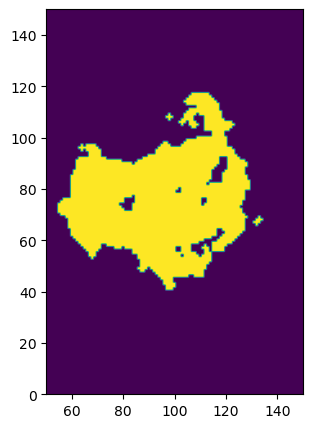

In [66]:
size = (5,5)
fig = plt.figure(figsize=size)
ds = 100
mx = int(np.max(tile.x) // ds) +1
my = int(np.max(tile.y) // ds) +1
tum = np.zeros((mx,my))
ntum = np.zeros((mx,my))
idx = tile.p_pos.values >= 0.5
xx = tile.loc[idx,'x'].astype(int) //ds  
yy = tile.loc[idx,'y'].astype(int) //ds 
tum[xx,yy] = 1 #tile.loc[idx,'p_pos']
local_mean = gaussian_filter(tum,sigma=1)
im = cv2.normalize(src=local_mean, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
_, im = cv2.threshold(im,  20, 255, 0,  cv2.THRESH_BINARY)
plt.imshow(im)
plt.ylim([0,150])
plt.xlim([50,150])

# Extract contours from this

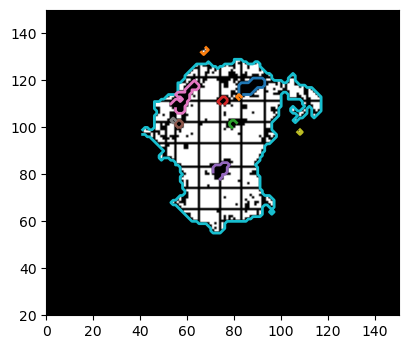

In [70]:
local_mean = gaussian_filter(tum,sigma=1)
im = cv2.normalize(src=local_mean, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
_, im = cv2.threshold(im,  20, 255, 0,  cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(im, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
size = (10,10)
fig = plt.figure(figsize=size)
ax = fig.add_subplot(1,2,1)
ax.imshow(tum.astype(int).T,cmap='gray')
ax.set_ylim([20,150])
ax.set_xlim([0,150])
for contour in contours:
    contour = np.squeeze(contour)
    ax.plot(contour[:, 1], contour[:, 0], linewidth=2)
contour_p = map(np.squeeze, contours)  # removing redundant dimensions
polygons = map(Polygon, contour_p)  # converting to Polygons
multipolygon = MultiPolygon(polygons)  # putting it all together in a MultiPolygon

# Example contours with cv2geojson package

/scratch/slurm-2186201/ipykernel_28728/2247665266.py:27: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  coords = np.array(feat["geometry"]["coordinates"])
/scratch/slurm-2186201/ipykernel_28728/2247665266.py:27: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  coords = np.array(feat["geometry"]["coordinates"])
/scratch/slurm-2186201/ipykernel_28728/2247665266.py:27: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you me

Finished


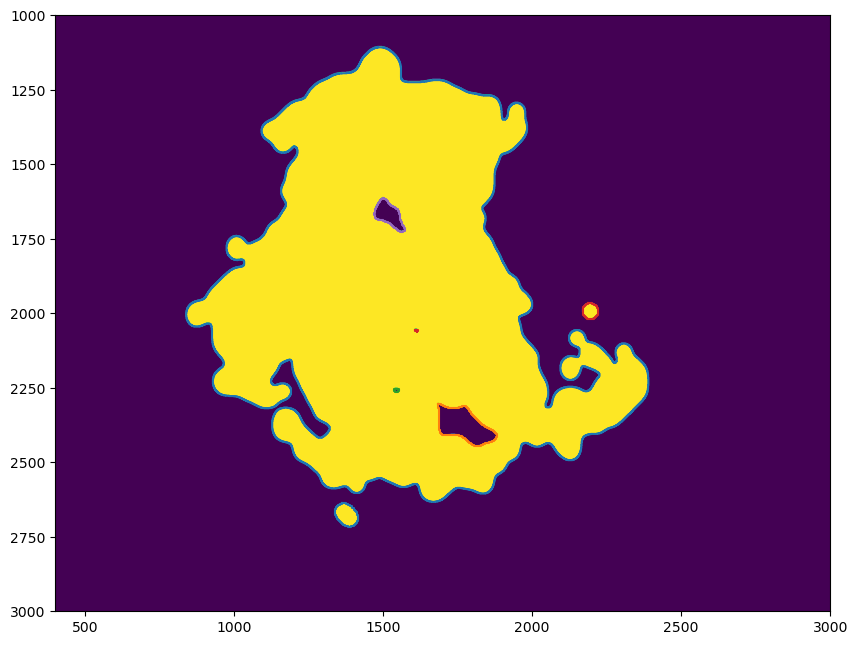

In [26]:
# Extract annotation contours
plot = True
tile_size = 224
if plot:
    fig = plt.figure(figsize=(10,10))
ds = 5
offset =  tile_size // 2
mx = int((np.max(tile.x) + offset) // ds) + 1
my = int((np.max(tile.y) + offset) // ds) + 1
tum = np.zeros((mx,my))
ntum = np.zeros((mx,my))
idx = tile.p_pos.values >= 0.5
xx = (tile.loc[idx,'x'].astype(int).values + offset) // ds  
yy = (tile.loc[idx,'y'].astype(int).values + offset) // ds 
tum[xx,yy] = 1 
tum = tum.T

local_mean = gaussian_filter(tum,sigma=100/ds)#100/ds)
im = cv2.normalize(src=local_mean, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
_, im = cv2.threshold(im,  20, 255, 0,  cv2.THRESH_BINARY)
geocontours = find_geocontours(im, mode='imagej')
features = [contour.export_feature(color=(0, 255, 0), label='Tumor') for contour in geocontours]
if plot:
    ax = fig.add_subplot(1,1,1)
    ax.imshow(im)
    for feat in features:
        coords = np.array(feat["geometry"]["coordinates"])
        for ii in range(0,len(coords)):
            coord = np.array(coords[ii])
            ax.plot(coord[:,0],coord[:,1])
    ax.set_ylim([x * (100/ds) for x in [50,150]])
    ax.set_xlim([x * (100/ds) for x in [20,150]])
    ax.invert_yaxis()
new_feats = []
for feat in tqdm(features):
    new_feat = feat
    coords = np.array(feat["geometry"]["coordinates"])
    if len(coords)> 1:
        multi_coord=[]
        for ii in range(0,len(coords)):
            coord = ((np.array(coords[ii]))*ds).tolist()
            multi_coord.append(coord)
        new_feat["geometry"]["coordinates"] = multi_coord
    else:
        new_feat["geometry"]["coordinates"] = (coords *ds ).tolist()
    new_feats.append(new_feat)
# export_annotations(new_feats, "/mnt/results/geojson_tests/%s_ds5_10sm_tile_offset_112px_p0.5.json" % str(df.slide.values[0]))
print('Finished')

In [11]:
def PolyArea(x,y):
    return 0.5*np.abs(np.dot(x,np.roll(y,1))-np.dot(y,np.roll(x,1)))

In [22]:
np.min(areas)

34225.0

In [31]:
 multi_area[0] - np.sum(np.array(multi_area)[1:]) #area minus holes

1762662.7066879272

3549.345657348633 1966616.2495438457


/scratch/slurm-2186201/ipykernel_28728/230145998.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  coords = np.array(feat['geometry']['coordinates'])  #Pixels


(array([101.,   2.,   0.,   0.,   1.,   0.,   0.,   0.,   1.,   1.]),
 array([   3549.34565735,  199856.036046  ,  396162.72643465,
         592469.4168233 ,  788776.10721195,  985082.7976006 ,
        1181389.48798925, 1377696.1783779 , 1574002.86876655,
        1770309.5591552 , 1966616.24954385]),
 <BarContainer object of 10 artists>)

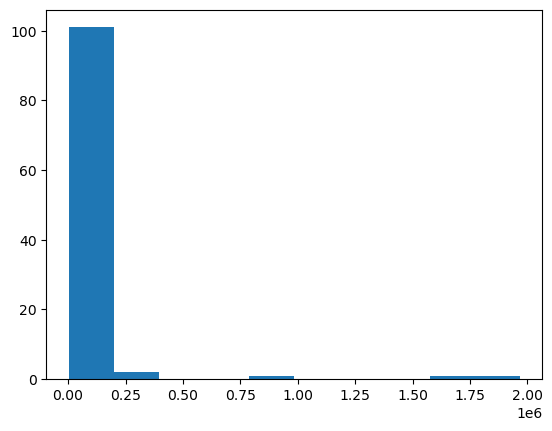

In [30]:
areas = []
for feat in new_feats:
    coords = np.array(feat['geometry']['coordinates'])  #Pixels
    if len(coords)> 1:
        multi_area=[]
        for ii in range(0,len(coords)):
            coord = np.array(coords[ii]) * 0.2517
            multi_area.append(PolyArea(coord[:,0],coord[:,1]))
        area = multi_area[0] - np.sum(np.array(multi_area)[1:]) #area minus holes
        areas.append(area)
    else:
        coords=np.squeeze(coords) * 0.2517
        areas.append(PolyArea(coords[:,0],coords[:,1]))
print(np.min(areas),np.max(areas))
plt.hist(np.array(areas))